# Secretion profiles in carbon samples

### TODO:
* Extract all EX_rxns for analysis
* which environment is linked to which saturation/C-chain length
* Use shadow prices/alpha or whatever
* inspect acetate and succinate samples to figure out which state they are in
    * retrieve index from alt_lipid_mod_samples

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D
import seaborn as sns

### Files:

In [ ]:
ex_rxns = pd.read_csv("/triumvirate/home/celinaha/thesis_files/ex_rxns.csv")

data = pd.read_pickle(DATA/"ml_datasets2/all_raw_samples.pkl")

In [169]:
# Set all lactose outliers to 0
data.loc[data['source'] == 'lcts', 'outlier'] = 0

# Set the two specific samples to 1
data.loc[data['sample'].isin(['lcts_sample_690', 'lcts_sample_757']),'outlier'] = 1

In [ ]:
mask = (
    (deviating_rows['outlier'] != 1) &
    (deviating_rows['outliers_2'] > 0.135)
)

samples_to_update = deviating_rows.loc[mask, 'sample']

data.loc[data['sample'].isin(samples_to_update), 'outlier'] = 1

In [8]:
bm_data = pd.read_pickle(DATA/"bm_all_samples.pkl")
bm_data = bm_data.drop(columns="biomass_type").set_index("reaction").T

In [10]:
lipid_devs = pd.read_csv("/triumvirate/home/celinaha/thesis_files/alt_lip_mod_samples.csv")

## PhPPs

In [24]:
def classify_phase(alpha):
    if alpha > 1000:
        return 'single_lim_inf'
    elif abs(alpha) <= 1e-15:
        return 'single_lim_zero'
    elif alpha < 0:
        return 'dual_lim'
    else:
        return 'futile'

In [100]:
color_map = sns.color_palette("GnBu", as_cmap=True)

source_titles = {
    'glc': 'Glucose',
    'ac': 'Acetate',
    'lcts': 'Lactose',
    'glyc': 'Glycerol',
    'succ': 'Succinate',
    'arg': 'Arginine',
    'nh4': 'Ammonium',
    'no3': 'Nitrate'
}

phase_labels = {
    'single_lim_inf': 'Single substrate limitation',
    'single_lim_zero': 'Single limitation (zero)',
    'dual_lim': 'Dual substrate limitation',
    'futile': 'Futile region'
}


def plot_by_source_subplots(
    plot_df,
    y_col,
    x_col=None,
    source_col='source',
    source_to_xcol=None,
    sources_to_plot=None,
    phase_col='phase',
    phase_colors=None,
    dataset=None,
    outlier_col='outlier',
    ncols=4,
    figsize_per_col=(5, 4),
    alpha=0.5,
    outlier_alpha=0.9,
    normal_marker='o',
    outlier_marker='x'
):
    """
    Plot one subplot per source value, with x-values chosen from mapped columns
    and points colored by phase. Outliers are marked with 'x' in the same color
    as their phase.

    Parameters
    ----------
    plot_df : pd.DataFrame
        DataFrame containing source column, y column, phase column, and x columns.
    y_col : str
        Column name to plot on the y-axis.
    source_col : str, default='source'
        Column containing source names like 'glc', 'arg_glc', etc.
    source_to_xcol : dict
        Mapping from source token -> dataframe x column.
    sources_to_plot : list, optional
        Ordered list of full source labels to include as subplots.
    phase_col : str, default='phase'
        Column containing phase labels used for coloring points.
    phase_colors : dict, optional
        Mapping from phase label -> color.
    dataset : pd.DataFrame, optional
        DataFrame containing outlier information aligned by index.
    outlier_col : str, default='outlier'
        Column in dataset used to identify outliers (1=True).
    ncols : int, default=4
        Number of subplot columns.
    figsize_per_col : tuple, default=(5, 4)
        Width, height per subplot grid unit.
    alpha : float, default=0.5
        Transparency for non-outlier points.
    outlier_alpha : float, default=0.9
        Transparency for outlier points.
    normal_marker : str, default='o'
        Marker for non-outliers.
    outlier_marker : str, default='x'
        Marker for outliers.

    Returns
    -------
    fig, axes
    """
    if source_to_xcol is None:
        raise ValueError("source_to_xcol must be provided.")

    if phase_colors is None:
        phase_colors = {
            'single_lim_inf': 'red',
            'single_lim_zero': 'blue',
            'dual_lim': 'green',
            'futile': 'gray'
        }

    df = plot_df.copy()


    if sources_to_plot is not None:
        df = df[df[source_col].isin(sources_to_plot)].copy()
        sources_present = [s for s in sources_to_plot if s in df[source_col].unique()]
    else:
        sources_present = list(df[source_col].dropna().unique())

    if len(sources_present) == 0:
        raise ValueError("No matching sources found to plot.")

    df['y_val'] = -df[y_col]
    
    if x_col is not None:
        df['x_val'] = -df[x_col]
        df['x_col'] = x_col
    else:
        df['x_token'] = df[source_col].str.split('_').str[0]
        df['x_col'] = df['x_token'].map(source_to_xcol)
        df = df.dropna(subset=['x_col']).copy()
        df['x_val'] = [-df.loc[idx, col_name] for idx, col_name in df['x_col'].items()]

    if dataset is not None and outlier_col in dataset.columns:
        df['is_outlier'] = dataset.loc[df.index, outlier_col].eq(1).values
    else:
        df['is_outlier'] = False

    n = len(sources_present)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_col[0] * ncols, figsize_per_col[1] * nrows)
    )

    if hasattr(axes, 'flatten'):
        axes = axes.flatten()
    else:
        axes = [axes]

    legend_seen = set()

    for i, src in enumerate(sources_present):
        ax = axes[i]
        sub = df[df[source_col] == src]

        if sub.empty:
            fig.delaxes(ax)
            continue

        for phase, color in phase_colors.items():
            sub_phase = sub[sub[phase_col] == phase]
            if sub_phase.empty:
                continue

            sub_normal = sub_phase[~sub_phase['is_outlier']]
            sub_outlier = sub_phase[sub_phase['is_outlier']]

            label = phase_labels.get(phase, phase) if phase not in legend_seen else None
            
            if not sub_normal.empty:
                ax.scatter(
                    sub_normal['x_val'],
                    # sub_normal[y_col],
                    sub_normal['y_val'],
                    alpha=alpha,
                    color=color,
                    marker=normal_marker,
                    label=label
                )
                if label is not None:
                    legend_seen.add(phase)
                    label = None

            if not sub_outlier.empty:
                ax.scatter(
                    sub_outlier['x_val'],
                    # sub_outlier[y_col],
                    sub_outlier['y_val'],
                    alpha=outlier_alpha,
                    color=color,
                    marker=outlier_marker,
                    label=label,
                    edgecolor='black',
                    s=90
                )
                if label is not None:
                    legend_seen.add(phase)

        # ax.set_title(src)
        parts = src.split('_')
        main_source = parts[0]
        title = source_titles.get(main_source, main_source)

        # for nitrogen sources, keep carbon source in parentheses
        if main_source in ['arg', 'nh4', 'no3'] and len(parts) > 1:
            carbon_source = parts[1]
            carbon_label = source_titles.get(carbon_source, carbon_source)
            title = f"{title} ({carbon_label})"
        ax.set_title(title, fontsize=15)

        # ax.set_xlabel(sub['x_col'].iloc[0], fontsize=14)
        # ax.set_ylabel(y_col, fontsize=14)

        if "(" in title:
            ax.set_xlabel(f"{title.split('(')[0].strip()} uptake", fontsize=14)
        else:
            ax.set_xlabel(f"{title} uptake", fontsize=14)
        ax.set_ylabel('Oxygen uptake', fontsize=14)

    for j in range(len(sources_present), len(axes)):
        fig.delaxes(axes[j])

    
    handles, labels = [], []

    for phase, color in phase_colors.items():
        if phase not in legend_seen:
            continue

        handles.append(
            Line2D(
                [0], [0],
                marker=normal_marker,
                color=color,
                markerfacecolor=color,
                markeredgecolor=color,
                linestyle='None',
                markersize=8
            )
        )
        labels.append(phase_labels.get(phase, phase))

    handles.append(
        Line2D(
            [0], [0],
            marker=outlier_marker,
            color='black',
            linestyle='None',
            markersize=8,
            label=r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
        )
    )
    labels.append(r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$')

    fig.legend(handles, labels, loc='lower right', fontsize=15)


    plt.tight_layout()
    return fig, axes

In [170]:
phpp = data.copy()
phpp["alpha"] =  -(phpp['source_shadow']/phpp['o2_e_shadow'])
phpp["phase"] = phpp["alpha"].apply(classify_phase)

In [76]:
sources_to_plot = [
    'glc', 'ac', 'lcts', 'glyc', 'succ',
    'arg_glc', 'arg_ac', 'arg_glyc',
    'nh4_glc', 'nh4_ac',
    'no3_glc', 'no3_glyc'
]

carbon_sources = ["glc", "ac", "lcts", "glyc", "succ"]

nitrogen_sources = [
    "arg_glc", "arg_ac", "arg_lcts", "arg_glyc", "arg_succ",
    "nh4_glc", "nh4_ac", "nh4_lcts", "nh4_glyc", "nh4_succ",
    "no3_glc", "no3_lcts", "no3_glyc", "no3_succ"
]

source_to_ex = {
    'glc': 'EX_glc__D_e',
    'ac': 'EX_ac_e',
    'lcts': 'EX_lcts_e',
    'glyc': 'EX_glyc_e',
    'succ': 'EX_succ_e',
    'arg': 'EX_arg__L_e',
    'nh4': 'EX_nh4_e',
    'no3': 'EX_no3_e'
}

phase_colors = {
    'single_lim_inf': 'purple',
    'single_lim_zero': 'teal',
    # 'dual_lim': color_map(1.0),
    'dual_lim': 'royalblue',
    'futile': 'olivedrab'
}

**C-sources**

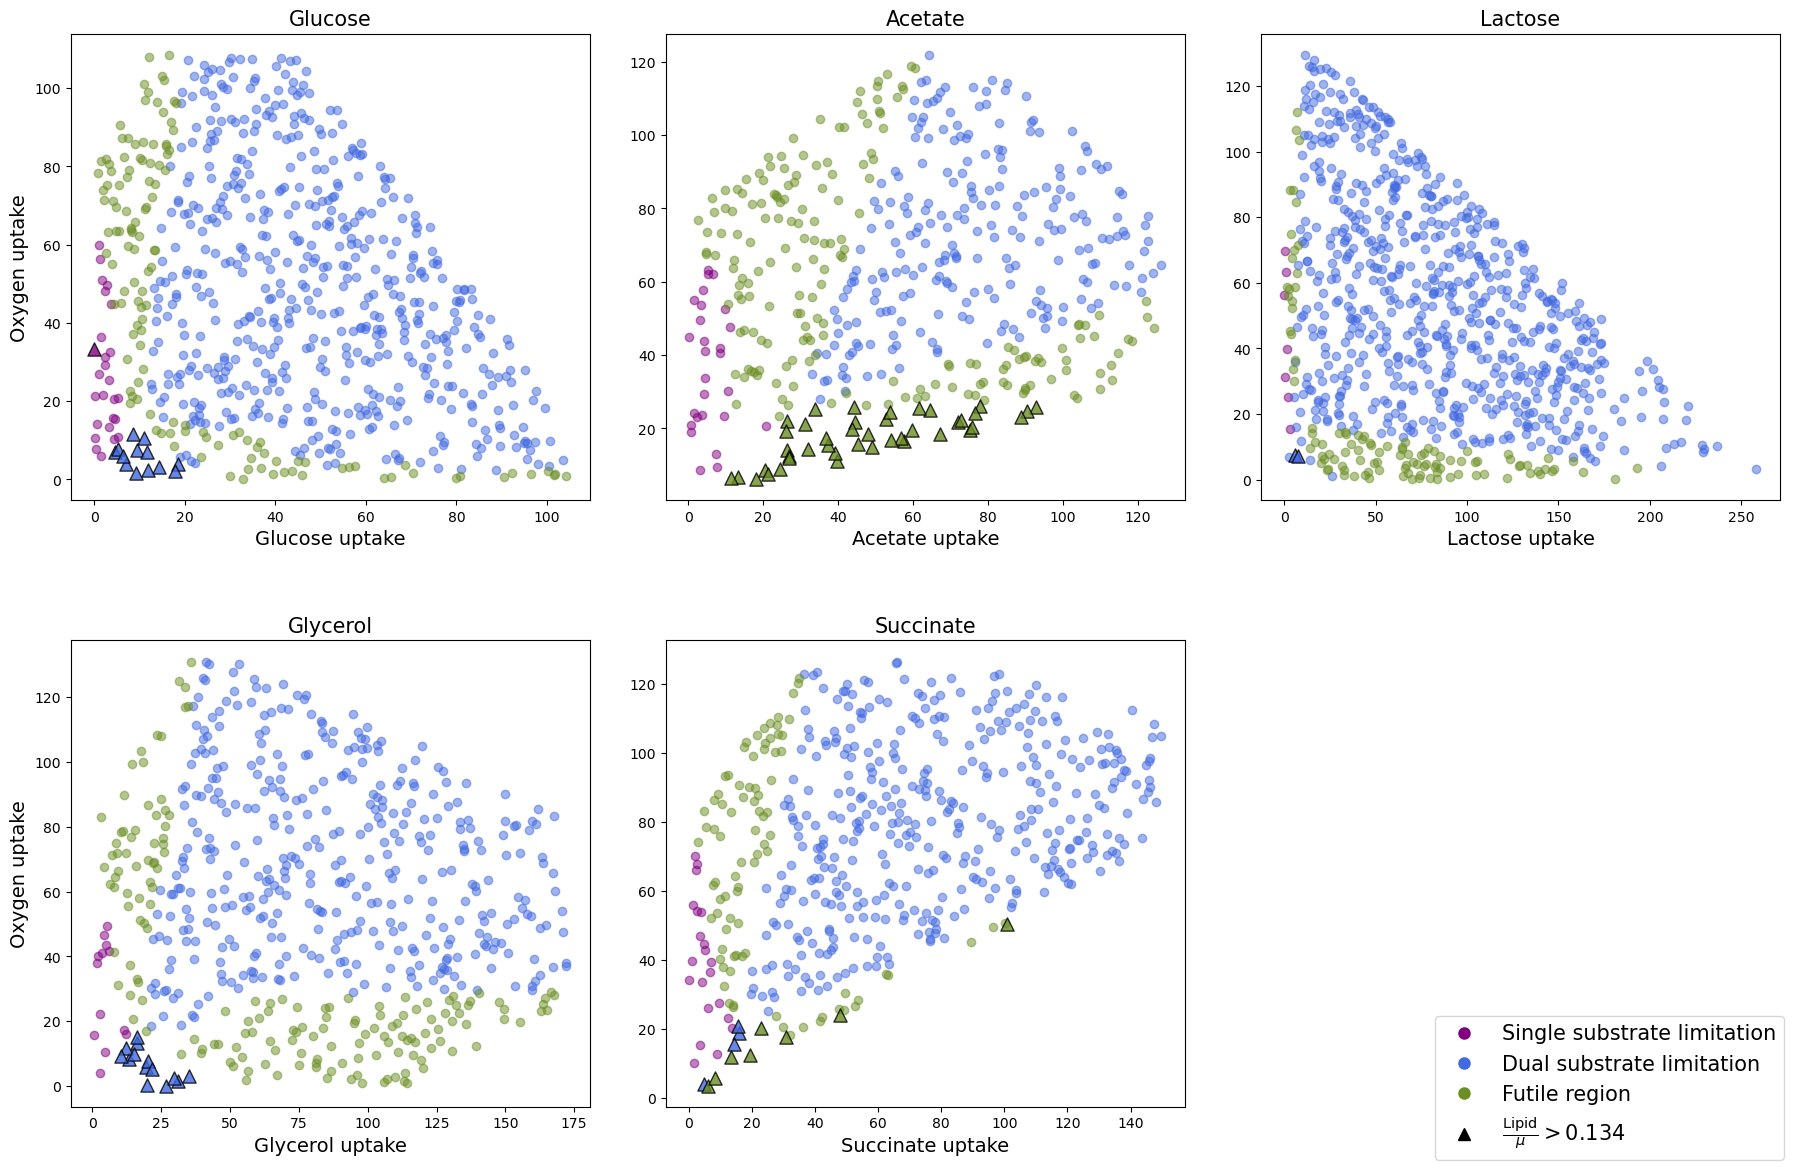

In [171]:
fig, axes = plot_by_source_subplots(
    plot_df=phpp,
    y_col='EX_o2_e',
    source_col='source',
    source_to_xcol=source_to_ex,
    sources_to_plot=carbon_sources,
    phase_col='phase',
    phase_colors=phase_colors,
    dataset=phpp,
    outlier_col='outlier',
    ncols=3,
    alpha=0.5,
    outlier_alpha=0.8,
    outlier_marker='^',
    figsize_per_col=(6,6),
    normal_marker='o'
)



# plt.suptitle('Phenotype phase planes - Carbon', fontsize=20)
plt.tight_layout(rect=[0, 0,1, 0.98])
plt.subplots_adjust(hspace=0.3)

# pos1 = axes[3].get_position()
# pos2 = axes[4].get_position()

# axes[3].set_position([0.15, pos1.y0, pos1.width, pos1.height])
# axes[4].set_position([0.60, pos2.y0, pos2.width, pos2.height])

axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")

plt.show()

**N-sources**

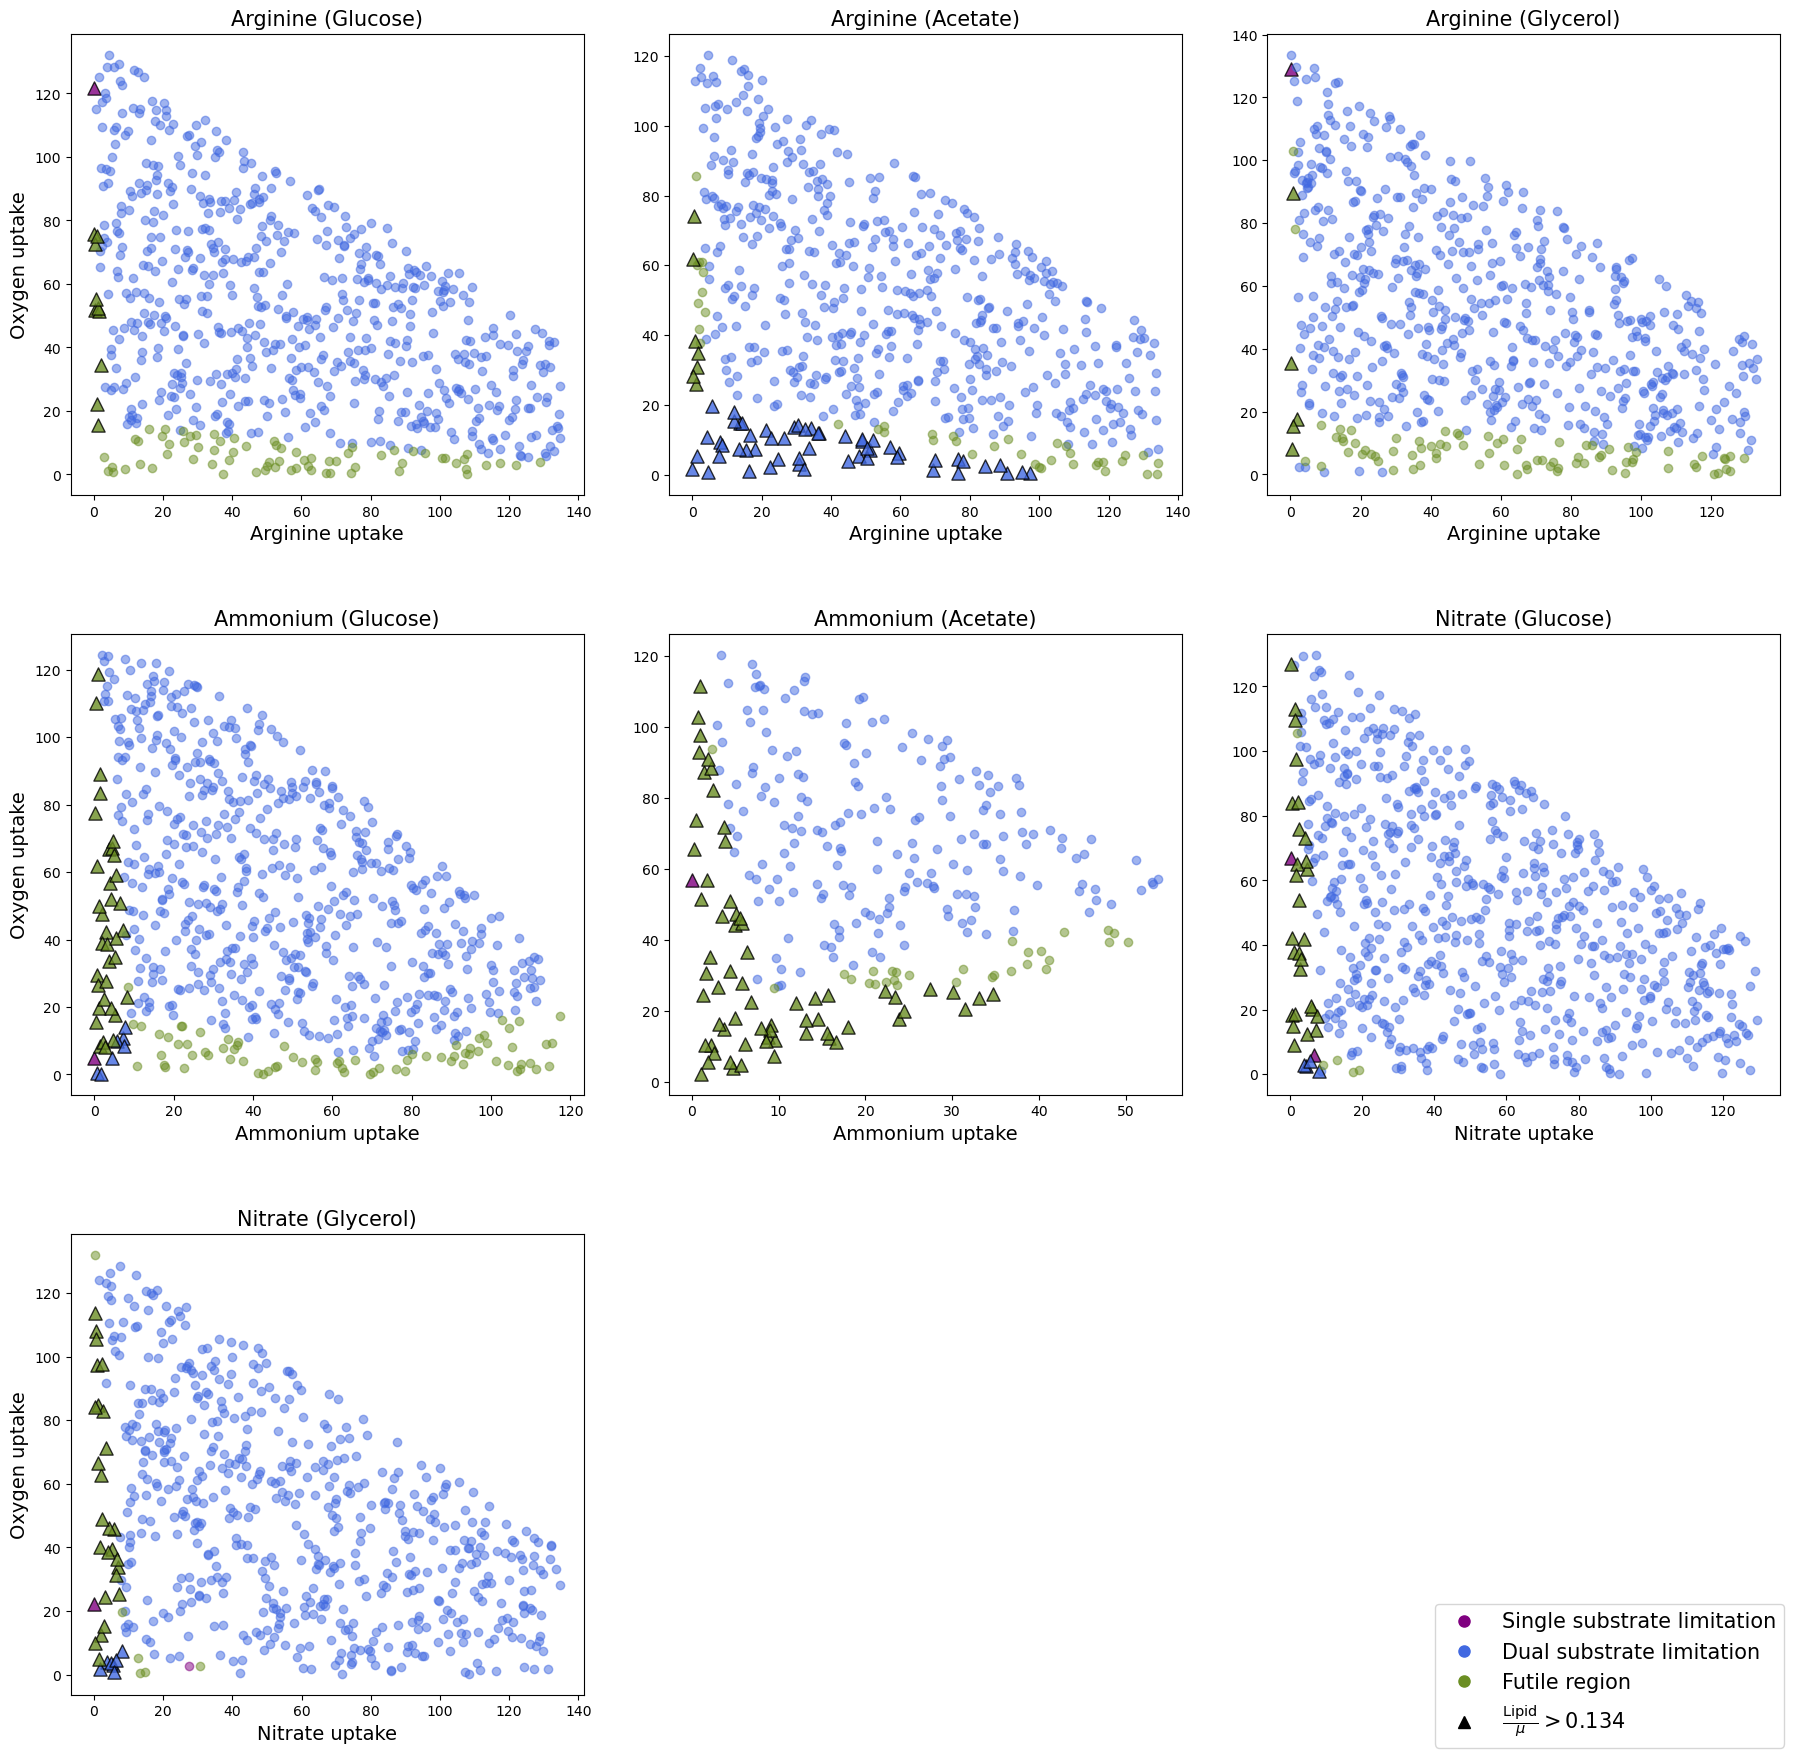

In [101]:
fig, axes = plot_by_source_subplots(
    plot_df=phpp,
    y_col='EX_o2_e',
    source_col='source',
    source_to_xcol=source_to_ex,
    sources_to_plot=nitrogen_sources,
    phase_col='phase',
    phase_colors=phase_colors,
    dataset=phpp,
    outlier_col='outlier',
    ncols=3,
    alpha=0.5,
    outlier_alpha=0.8,
    outlier_marker='^',
    figsize_per_col=(6,6),
    normal_marker='o'
)



# plt.suptitle('Phenotype phase planes - Carbon', fontsize=20)
plt.tight_layout(rect=[0, 0,1, 0.98])
plt.subplots_adjust(hspace=0.3)

axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[4].set_ylabel("")
axes[5].set_ylabel("")

plt.show()

# C-sources

In [127]:
def add_phase_legend(fig, df, phase_colors, phase_labels,
                     outlier_mask=None, lipid_mask=None,
                     fontsize=15, loc='lower right'):

    handles = []
    labels = []

    # Only phases actually present in df
    phases_present = df['phase'].dropna().unique()

    for phase, color in phase_colors.items():
        if phase not in phases_present:
            continue

        handles.append(
            Line2D(
                [0], [0],
                marker='o',
                color=color,
                markerfacecolor=color,
                markeredgecolor=color,
                linestyle='None',
                markersize=8
            )
        )
        labels.append(phase_labels.get(phase, phase))

    # Only add outlier label if there are actually outliers
    if outlier_mask is not None and outlier_mask.any():
        handles.append(
            Line2D(
                [0], [0],
                marker='^',
                color='black',
                markerfacecolor='black',
                linestyle='None',
                markersize=9
            )
        )
        labels.append(r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$')

    # Only add Lpp label if there are actually lipid-mask points
    if lipid_mask is not None and lipid_mask.any():
        handles.append(
            Line2D(
                [0], [0],
                marker='D',
                color='black',
                markerfacecolor='black',
                linestyle='None',
                markersize=9
            )
        )
        labels.append('Alternative Lpp modification')

    fig.legend(handles, labels, fontsize=fontsize, loc=loc)

In [212]:
def add_phase_legend(fig, df, phase_colors, phase_labels,
                     outlier_mask=None, lipid_mask=None,
                     fontsize=15, loc='lower right', bbox_to_anchor=None):

    handles = []
    labels = []

    # Only phases actually present in df
    phases_present = df['phase'].dropna().unique()

    for phase, color in phase_colors.items():
        if phase not in phases_present:
            continue

        handles.append(
            Line2D(
                [0], [0],
                marker='o',
                color=color,
                markerfacecolor=color,
                markeredgecolor=color,
                linestyle='None',
                markersize=8
            )
        )
        labels.append(phase_labels.get(phase, phase))

    # High Lipid/mu WITHOUT alternative Lpp state
    if outlier_mask is not None and lipid_mask is not None:
        outlier_no_lpp = outlier_mask & ~lipid_mask

        if outlier_no_lpp.any():
            handles.append(
                Line2D(
                    [0], [0],
                    marker='D',
                    color='black',
                    markerfacecolor='black',
                    markeredgecolor='black',
                    linestyle='None',
                    markersize=9
                )
            )
            labels.append(
                r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$'
            )

        # High Lipid/mu WITH alternative Lpp state
        outlier_lpp = outlier_mask & lipid_mask

        if outlier_lpp.any():
            handles.append(
                Line2D(
                    [0], [0],
                    marker='D',
                    color='black',
                    markerfacecolor='none',
                    markeredgecolor='black',
                    linestyle='None',
                    markersize=9
                )
            )
            labels.append(
                r'$\frac{\mathrm{Lipid}}{\mu} > 0.134$ & alternative Lpp mod'
            )

    fig.legend(
        handles,
        labels,
        fontsize=fontsize,
        loc=loc, 
        bbox_to_anchor=bbox_to_anchor
    )

## PhPPs phases + marking lipid mod

In [172]:
phpp["lipid_dev"] = (bm_data["b1677_lipid_modification_pg120_p_pe160"].ne(0).astype(int).to_numpy())

In [173]:
lipid_mask = phpp["lipid_dev"] == 0
outlier_mask = phpp["outlier"] == 1

In [174]:
glc = phpp[phpp["source"]=="glc"]
ac = phpp[phpp["source"]=="ac"]
glyc = phpp[phpp["source"]=="glyc"]
lac = phpp[phpp["source"]=="lcts"]
succ = phpp[phpp["source"]=="succ"]

In [242]:
# fig, axes = plt.subplots(1, 2, figsize=(25, 8))

# # sc = plt.scatter(_df['PC1'], pca_df['PC2'], c=pca_df['biomass_dilution'], cmap=color_map, edgecolors='black', linewidths=0.3)

# # Plot first column

# for phase, color in phase_colors.items():
#     phase_mask = glc['phase'] == phase

#     axes[0].scatter(-glc.loc[phase_mask & ~outlier_mask & ~lipid_mask, 'EX_glc__D_e'], -glc.loc[phase_mask & ~outlier_mask & ~lipid_mask, 'EX_o2_e'], color=color, marker='o', alpha=0.5)
#     axes[0].scatter(-glc.loc[phase_mask & outlier_mask & ~lipid_mask, 'EX_glc__D_e'], -glc.loc[phase_mask & outlier_mask & ~lipid_mask, 'EX_o2_e'], color=color, marker='D', alpha=0.8, s=90, edgecolors='black')
#     axes[0].scatter(-glc.loc[phase_mask & lipid_mask, 'EX_glc__D_e'], -glc.loc[phase_mask & lipid_mask, 'EX_o2_e'], marker='D', s=90, facecolors='none', edgecolors=color, linewidth=2)
#     axes[0].set_xlabel('Glucose uptake', fontsize=15)
#     axes[0].set_ylabel('Oxygen uptake', fontsize=15)

#     phase_mask = ac['phase'] == phase
#     axes[1].scatter(-ac.loc[phase_mask & ~outlier_mask & ~lipid_mask, 'EX_ac_e'], -ac.loc[phase_mask & ~outlier_mask & ~lipid_mask, 'EX_o2_e'], color=color, marker='o', alpha=0.5)
#     axes[1].scatter(-ac.loc[phase_mask & outlier_mask & ~lipid_mask, 'EX_ac_e'], -ac.loc[phase_mask & outlier_mask & ~lipid_mask, 'EX_o2_e'], color=color, marker='D', alpha=0.8, s=90, edgecolor='black')
#     axes[1].scatter(-ac.loc[phase_mask & lipid_mask, 'EX_ac_e'], -ac.loc[phase_mask & lipid_mask, 'EX_o2_e'], marker='D', s=90, facecolors='none', edgecolor=color, linewidth=2)
#     axes[1].set_xlabel('Acetate uptake', fontsize=15)
#     axes[1].set_ylabel('', fontsize=15)

# # Panel labels
# axes[0].text(-0.05, 1.05, "A", transform=axes[0].transAxes, fontsize=30, fontweight="bold", va="top")
# axes[1].text(-0.05, 1.05, "B", transform=axes[1].transAxes, fontsize=30, fontweight="bold", va="top")


# # add_phase_legend(fig, glc, phase_colors, phase_labels, outlier_mask, lipid_mask, loc='upper right')

# plt.suptitle("knfk", color="white", fontsize=25)
# # fig.legend(fontsize=15)
# plt.subplots_adjust(wspace=0.1)
# plt.show()

In [244]:
def plot_phpps_lipid_devs(df1, df2, x_col1, x_col2, x_name1, x_name2, y_col, y_name, sub_1, sub_2, include_legend):

    fig, axes = plt.subplots(1, 2, figsize=(25, 8))
    for phase, color in phase_colors.items():
        phase_mask = df1['phase'] == phase

        axes[0].scatter(-df1.loc[phase_mask & ~outlier_mask & ~lipid_mask, x_col1], -df1.loc[phase_mask & ~outlier_mask & ~lipid_mask, y_col], color=color, marker='o', alpha=0.5)
        axes[0].scatter(-df1.loc[phase_mask & outlier_mask & ~lipid_mask, x_col1], -df1.loc[phase_mask & outlier_mask & ~lipid_mask, y_col], color=color, marker='D', alpha=0.8, s=90, edgecolors='black')
        axes[0].scatter(-df1.loc[phase_mask & lipid_mask, x_col1], -df1.loc[phase_mask & lipid_mask, y_col], marker='D', s=90, facecolors='none', edgecolors=color, linewidth=2)
        axes[0].set_xlabel(f'{x_name1} uptake', fontsize=15)
        axes[0].set_ylabel(f'{y_name} uptake', fontsize=15)

        phase_mask = df2['phase'] == phase
        axes[1].scatter(-df2.loc[phase_mask & ~outlier_mask & ~lipid_mask, x_col2], -df2.loc[phase_mask & ~outlier_mask & ~lipid_mask, y_col], color=color, marker='o', alpha=0.5)
        axes[1].scatter(-df2.loc[phase_mask & outlier_mask & ~lipid_mask, x_col2], -df2.loc[phase_mask & outlier_mask & ~lipid_mask, y_col], color=color, marker='D', alpha=0.8, s=90, edgecolor='black')
        axes[1].scatter(-df2.loc[phase_mask & lipid_mask, x_col2], -df2.loc[phase_mask & lipid_mask, y_col], marker='D', s=90, facecolors='none', edgecolor=color, linewidth=2)
        axes[1].set_xlabel(f'{x_name2} uptake', fontsize=15)
        axes[1].set_ylabel('', fontsize=15)


    # Panel labels
    axes[0].text(-0.05, 1.05, sub_1, transform=axes[0].transAxes, fontsize=30, fontweight="bold", va="top")
    axes[1].text(-0.05, 1.05, sub_2, transform=axes[1].transAxes, fontsize=30, fontweight="bold", va="top")

    if include_legend == True:
        add_phase_legend(fig, df1, phase_colors, phase_labels, outlier_mask, lipid_mask, loc='upper right')
    plt.suptitle("knfk", color="white", fontsize=25)
    plt.subplots_adjust(wspace=0.1)
    plt.show()

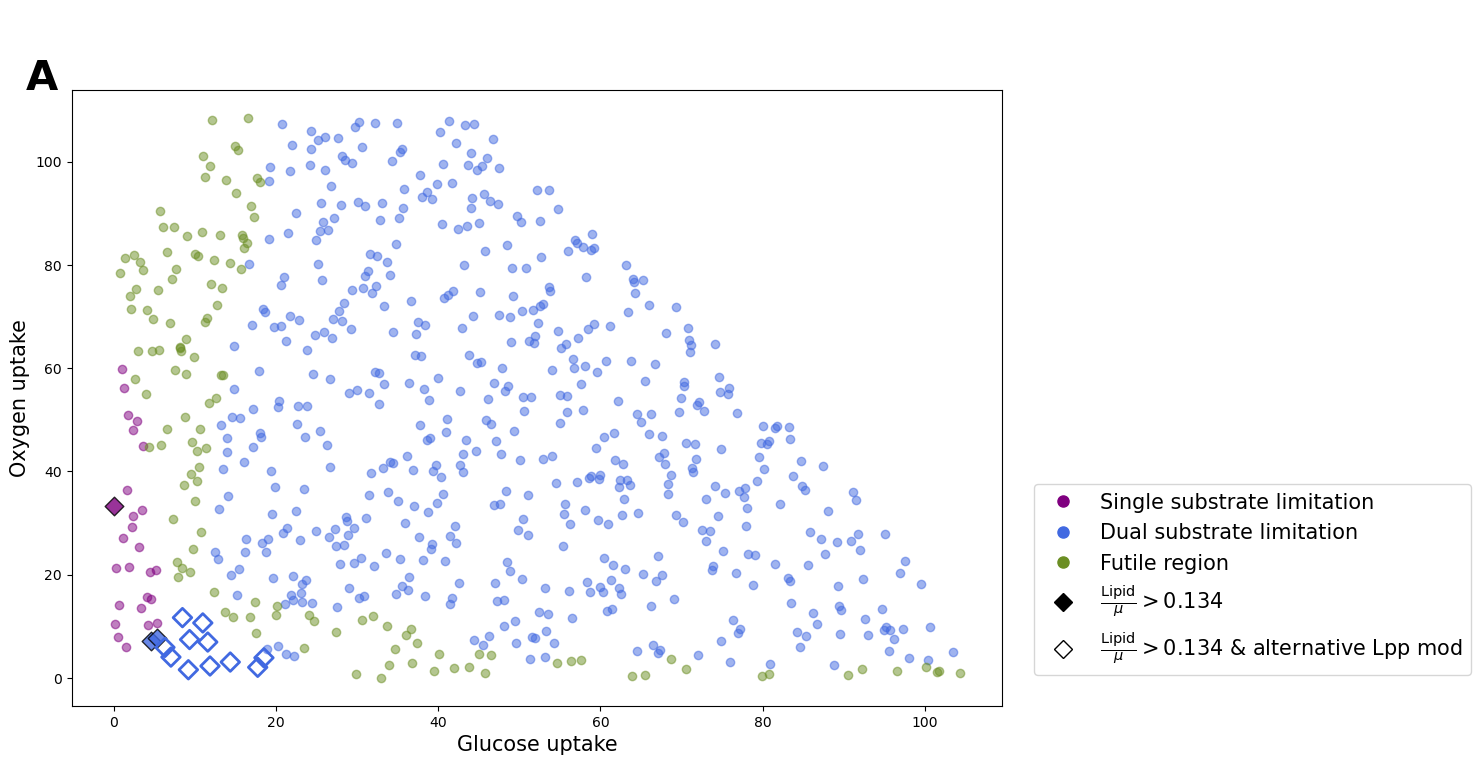

In [249]:
fig, ax = plt.subplots(figsize=(12, 8))

for phase, color in phase_colors.items():
    phase_mask = glc['phase'] == phase

    ax.scatter(-glc.loc[phase_mask & ~outlier_mask & ~lipid_mask, 'EX_glc__D_e'], -glc.loc[phase_mask & ~outlier_mask & ~lipid_mask, 'EX_o2_e'], color=color, marker='o', alpha=0.5)
    ax.scatter(-glc.loc[phase_mask & outlier_mask & ~lipid_mask, 'EX_glc__D_e'], -glc.loc[phase_mask & outlier_mask & ~lipid_mask, 'EX_o2_e'], color=color, marker='D', alpha=0.8, s=90, edgecolors='black')
    ax.scatter(-glc.loc[phase_mask & lipid_mask, 'EX_glc__D_e'], -glc.loc[phase_mask & lipid_mask, 'EX_o2_e'], marker='D', s=90, facecolors='none', edgecolors=color, linewidth=2)
    ax.set_xlabel('Glucose uptake', fontsize=15)
    ax.set_ylabel('Oxygen uptake', fontsize=15)

# Panel labels
ax.text(-0.05, 1.05, "A", transform=ax.transAxes, fontsize=30, fontweight="bold", va="top")


add_phase_legend(fig, glc, phase_colors, phase_labels, outlier_mask, lipid_mask, loc='upper right', bbox_to_anchor=(1.3, 0.4))

plt.suptitle("knfk", color="white", fontsize=25)
# fig.legend(fontsize=15)
plt.subplots_adjust(wspace=0.1)
plt.show()

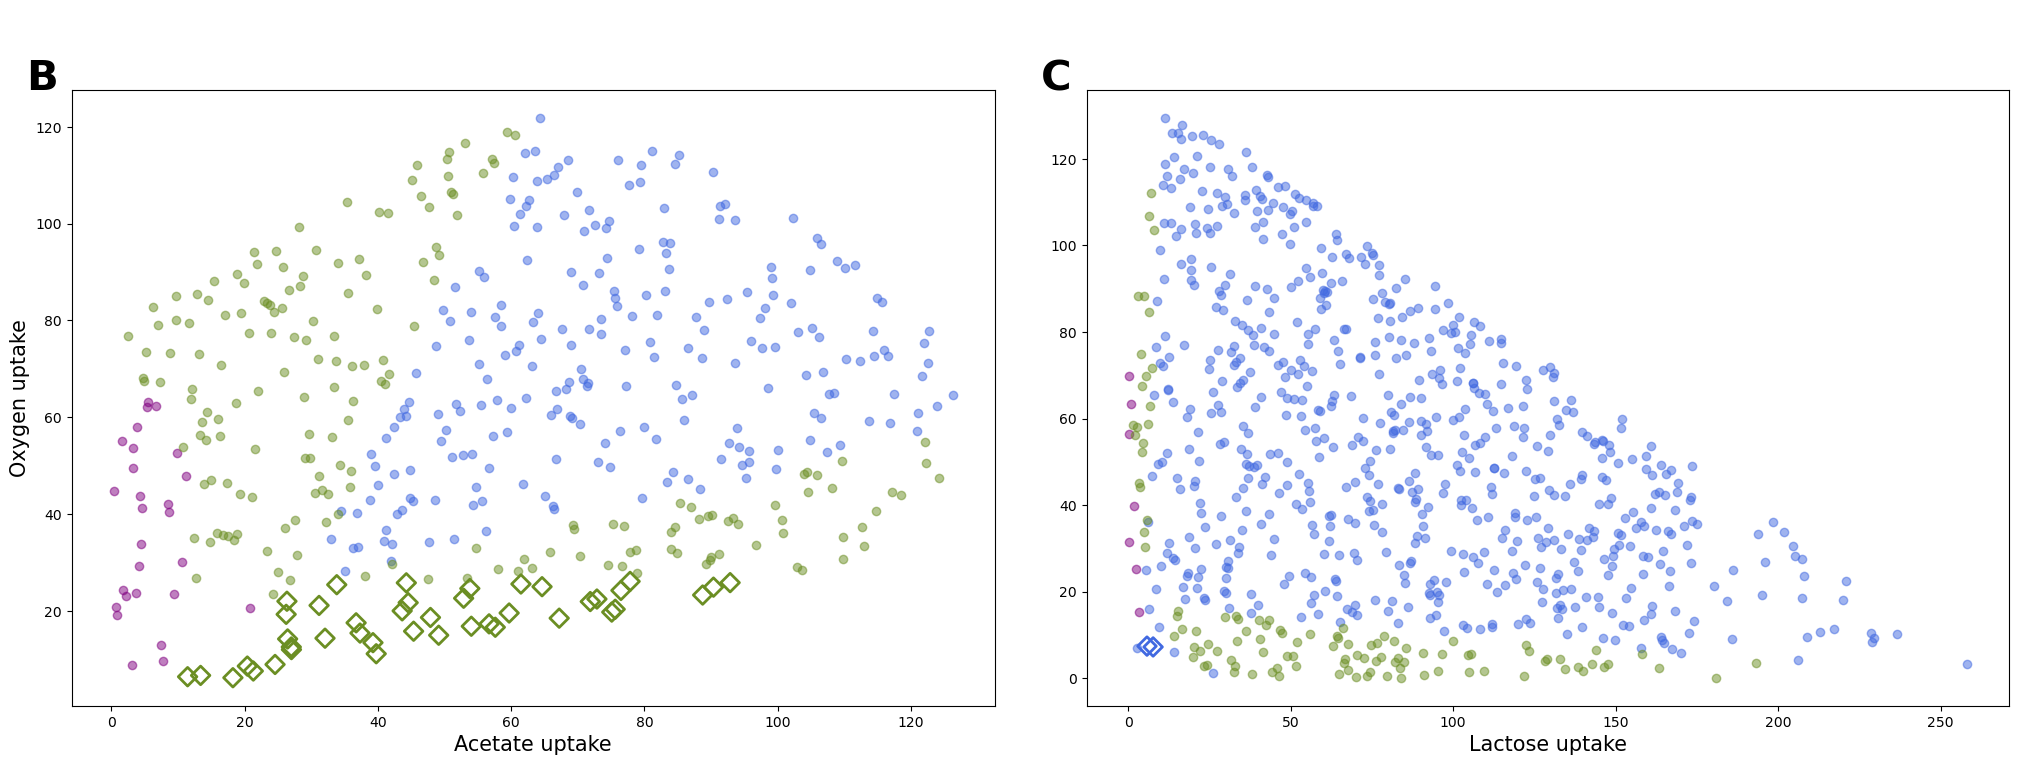

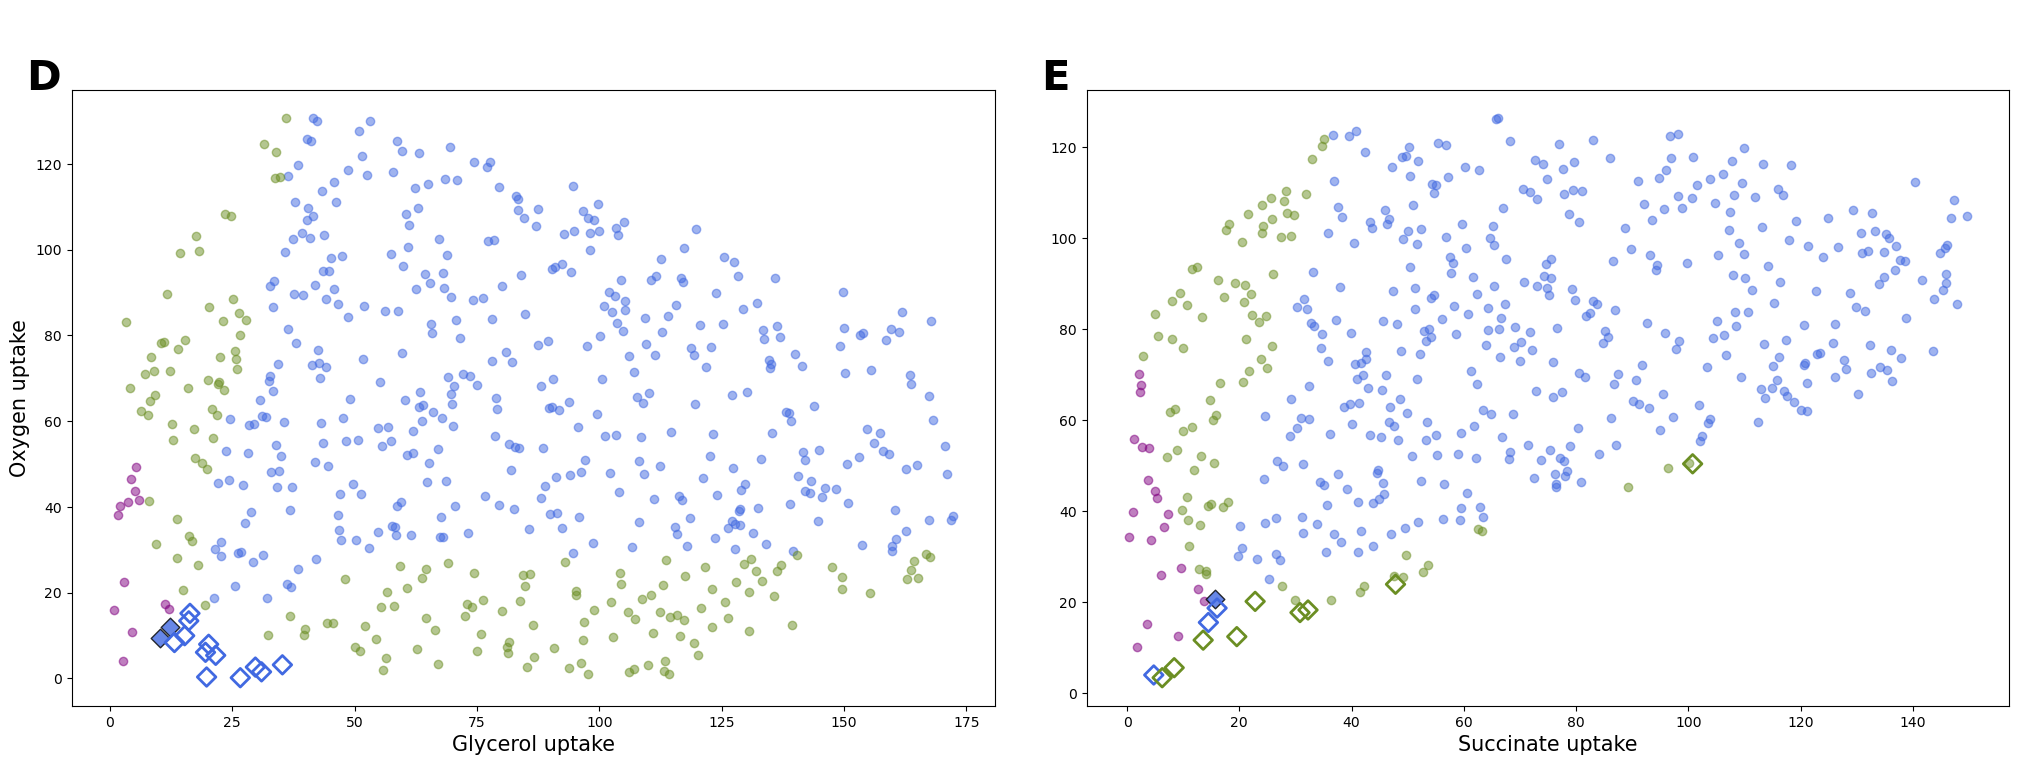

In [245]:

plot_phpps_lipid_devs(ac, lac, "EX_ac_e", "EX_lcts_e", "Acetate", "Lactose", "EX_o2_e", "Oxygen", "B", "C", False)
plot_phpps_lipid_devs(glyc, succ, "EX_glyc_e", "EX_succ_e", "Glycerol", "Succinate", "EX_o2_e", "Oxygen", "D", "E", False)
# plot_phpps_lipid_devs(glyc, "EX_glyc_e", "Glycerol", "EX_o2_e", "Oxygen", "G", "H", False)

## Metabolic states in deviations

### 1. Glucose